# Analise Exploratória de Dados.

A analise exploratória de dados (AED) é uma abordagem investigativa para a análise de dados, que utiliza um conjunto de técnicas (principalmente visuais e estatísticas) para:


* Sintetizar e descrever as principais características dos dados.
* Descobrir padrões, tendências e relações.
* Identificar anomalias, outliers e dados ausentes.
* Verificar suposições e formular hipóteses que poderão ser testadas.

Para iniciarmos devemos ter respondido algumas perguntas, dentre elas é qual o meu conhecimento sobre o assunto que vou explorar, qual o meu objetivo com estes dados (tenho alguma hipótese),o que eu sei sobre os dados (metadados,estrutura e suas variáveis).

Neste exemplo, trabalharemos com os dados do naufrágio do Titanic.
Nosso objetivo é investigar quais variáveis impactaram na condição de sobrevivência (variável alvo).

Vamos iniciar carregando alguns pacotes que irão nos auxiliar no processo.


In [ ]:
# pacotes a instalar
#!pip install skimpy

# pacotes básicos para analise exploratória de dados
import pandas as pd # manipulação de dataframes
import numpy as np # trabalhar com números de forma eficiente, manipulação de arrays
import matplotlib.pyplot as plt # fazer gráficos
import seaborn as sns# fazer gráficos
import statsmodels.api as sm # estatística, econometria e modelagem preditiva.
from scipy.stats import skew, kurtosis, kruskal # estatística
#from skimpy import skim # resumo estatístico

# estilo dos gráficos do Seaborn
sns.set_style("whitegrid")


In [ ]:
# carregando dados do titanic

df = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv')

# remover observações(linhas) duplicados (se houver)
df.drop_duplicates(inplace=True) # inplace já ajusta o df, df.drop_duplicates(subset=['col1', 'col2'], inplace=True) para se basear em alguams colunas

A partir de agora o nosso *dataframe* que contem os dados do acidente do Titanic será chamado de `df`.

O primeiro ponto que temos que estar a par a cerca do dataframe é sobre a estrutura e os nomes da variavies, bem como o que cada uma significa.

* pclass - Classe do passageiro alvo

* survived - sobreviveu (0 = não, 1 = sim) (ALVO)

* name - Nome do passageiro

* sex - Sexo do passageiro

* age - Idade do passageiro

* sibsp - Número de irmãos/esposa/marido embarcados

* parch - Número de pais/filhos embarcados

* ticket - Número do bilhete de passagem

* fare - Preço da passagem

* cabin - cabine

* embarked - Local de embarque

Observar as primeiras linhas do banco de dados é essencial para dar inicio a analise, para vermos se os dados corresponde as informações que temos a cerca dos dados, bem como ver se foi carregado corretamente.

Obs: Dica Pratica, se possível abra o dado algum programa como notepad++ ou na sua EDE de preferencia e faça uma inspeção inicial para evitar surpresas principalmente na hora de carregá-lo.


In [ ]:

df.head(10)# cinco primeiras como padrão, mas 10 temos uma melhor compreenção

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Obter informações básicas sobre a estrutura dos dados é primordial para isso podemos usar o recurso `info()`

*    Número de colunas e quantas observações (Linhas)
*    Número de linhas com conteúdo não nulos (NaN/NA, None), Note que valores com (" ",' ',0) são computados como não nulos
*    Uso de memoria
*  Qual o tipo de cada coluna:

| `dtype`              | Significado                        | Memória   | Uso comum                     |
|------------------------------------|-----------|----------------|-------------------------------|
| `int64`              | Inteiro (64 bits)                  | 8 bytes   | IDs, contagens                |
| `int32`              | Inteiro (32 bits)                  | 4 bytes   | Economizar memória            |
| `float64`            | Ponto flutuante (64 bits)          | 8 bytes   | Preços, notas, `NaN`          |
| `float32`            | Ponto flutuante (32 bits)          | 4 bytes   | Dados grandes, menos precisão |
| `object`             | Texto ou misto (strings, listas)   | Alta      | Nomes, textos livres          |
| `bool`               | Verdadeiro/Falso                   | 1 byte    | Flags: ativo, sim/não         |
| `datetime64[ns]`     | Data e hora (nanosegundos)         | 8 bytes   | `pd.to_datetime()`            |
| `category`           | Valores categóricos (poucos únicos)| Baixa     | Sexo, UF, status              |

---
 Comandos Úteis

```python
df.dtypes                    # Ver todos os dtypes
df.info()                    # Non-Null + Dtype + Memória
df['col'].astype('int64')    # Troca formato
df.memory_usage(deep=True)   # Uso real de memória



In [ ]:
#informações basicas Sobre o data frame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Note que o `info()` trás informação importante, mas muito rasa, podemos melhorar, saber valores ausentes, valores únicos, e valores zero.

Obs: Nem sempre encontraremos recuros prontos, podemos adaptar o que temos ou gerar a nosso proprio resumo. Com o tempo ganhamos ritos(metodos) proprios  de analisar os dados e criamos as nossas proprias funções.  

In [ ]:
# vamos criar um função para obter informações sobre valores ausentes, zeros e valores unicos.
def generate_summary(df):

  summary_data = []
  for column in df.columns:
    na_count = df[column].isnull().sum()
    zero_count = (df[column] == 0).sum()

    summary_data.append([
        column,
        df[column].nunique(), # valores unicos
        na_count,
        na_count / len(df) * 100,
        zero_count,
        zero_count / len(df) * 100,
        df[column].dtype
    ])

  summary_df = pd.DataFrame(summary_data, columns=[
      'variavel',
      'Únicos',
      'NA',
      '% de NA',
      'Zeros',
      '% de Zeros',
      'Tipo'
  ])

  return summary_df

# usando a função criada
generate_summary(df)

,variavel,Únicos,NA,% de NA,Zeros,% de Zeros,Tipo
0,PassengerId,891,0,0.000000,0,0.000000,int64
1,Survived,2,0,0.000000,549,61.616162,int64
2,Pclass,3,0,0.000000,0,0.000000,int64
3,Name,891,0,0.000000,0,0.000000,object
4,Sex,2,0,0.000000,0,0.000000,object
5,Age,88,177,19.865320,0,0.000000,float64
6,SibSp,7,0,0.000000,608,68.237935,int64
7,Parch,7,0,0.000000,678,76.094276,int64
8,Ticket,681,0,0.000000,0,0.000000,object
9,Fare,248,0,0.000000,15,1.683502,float64


-Colunas com baixa variabilidade (variáveis com valor unico ou muito próximo disso, sendo numéricas, não trazem informação) podem ser removidas (engenharia de recursos).

-Levantamos informações pertinentes para o pré processamento como uso codificadores.

* Número de NA:

-determinar estrategias de imputação

-Ajudar na escolha de modelos (alguns modelos não aceitam NA)

-NA podem ser indicativos de erros na observação/coleta/manipulação/carregamento

* Valores iguais a ZERO

-Verificar se o zero é real ou NA.

Obs: Cuidar valores como -99, -999.99 e suas variações que são tradicionalmente usados como NA.

-Distorções de distribuição puxando medias/medianas para baixo.

-Muitos zeros podem complicar para alguns modelos, sendo necessário algumas modificações, cuidar também variáveis que entram em log(0)=-Inf

* tipo de variável: é ponto de partida da analise, veremos que cada tipo de variável vai receber tratamento e analise diferenciada. Muito importante analisar conjuntamente com os demais aspectos.

Os dados ausentes temos que levar em conta além do numero absoluto/percentual a sua distribuição. Novamente a sua distribuição vai ser levada em conta na hora de tomar atitudes quanto a imputação, como preencher ou remover a variável.


Obs: em BD relacionais temos mais (como integridade)


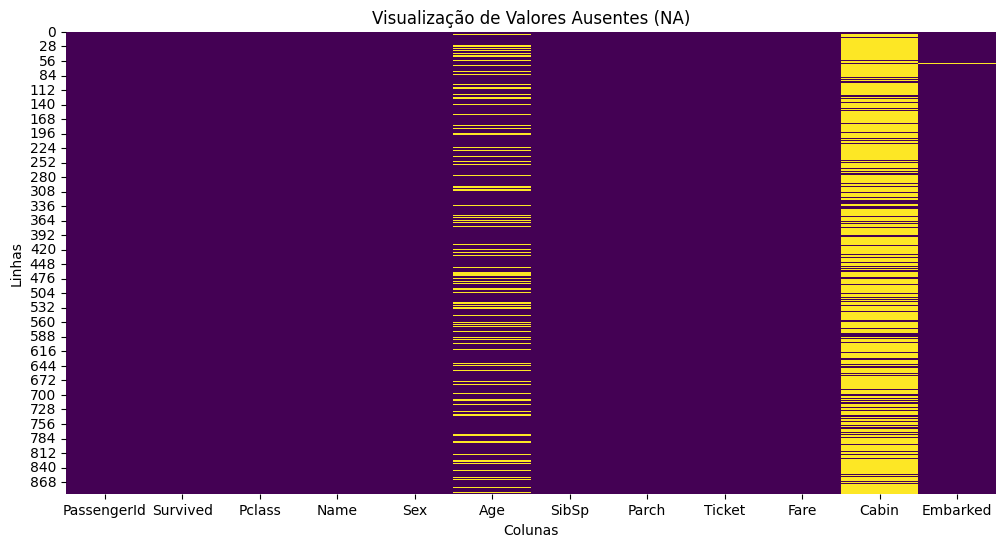

In [ ]:
#Visualisação grafica dos ausentes
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Visualização de Valores Ausentes (NA)')
plt.xlabel('Colunas')
plt.ylabel('Linhas')
plt.show()

Essa avaliação inicial da Qualidade dos dados é importante e deve manter se ao longo de toda EDA.

Quais aspectos temos que ter atenção quanto a qualidade dos dados:


* Consistência: Verifica se os dados não se contradizem e seguem regras lógicas internas (datas estão em sequencia, coluna de temperatura máxima > temperatura mínima).
* Completude: valores ausente

* Unicidade: Examinar se cada registro é único, sem duplicações desnecessárias.
* Acurácia: Avalia se o dado representa corretamente a realidade, ou seja, se está correto. (idade : 6 anos (escolaridade: Ensino superior), chuva: 1000 mm em uma dia, escolaridade: Masculino)
* Validade: Verifica se os valores seguem regras de formato, domínio ou faixa permitida. (estado: RS, esperado Rio grande do Sul.)

Obs: em BD relacionais temos mais (como integridade)





In [ ]:
# remover variaveis que não utilizaremos na nossa analise.
df = df.drop(['PassengerId', 'Embarked', 'Ticket', 'Cabin'], axis=1)


# transformar em categorias algumas variaveis como estavam como objeto.
df['Pclass'] = df['Pclass'].astype('category')
df['Sex'] = df['Sex'].astype('category')
df['Survived'] = df['Survived'].astype('category')

#>>> poderiamos automatizar
for column in df.columns:
  if pd.api.types.is_numeric_dtype(df[column]) and df[column].nunique() < 8: # verifica se temos valores numericos com menos de 8 valores unicos
    df[column] = df[column].astype('category') # transforma em categorico

#  if not pd.api.types.is_numeric_dtype(df[column]):
#    df[column] = df[column].astype('category')

# transformar Pclass para ordenado
df['Pclass'] = pd.Categorical(df['Pclass'], categories=[1, 2, 3], ordered=True)


df.dtypes

,0
Survived,category
Pclass,category
Name,object
Sex,category
Age,float64
SibSp,category
Parch,category
Fare,float64


# Analise Univariada

Apos verificarmos a estrutura e qualidade dos dados, desejamos conhecer as características individuais de cada variável. Para isso vamos usar de estatísticas descritiva básicas, tabelas e elementos gráficos sobre cada variavel de forma particular (Analise Univariada).

Funções de resumo, como o `describe` para variáveis numéricas, são uteis para termos um panorama geral dos valores numéricos.

In [ ]:
df.describe()

,Age,Fare
count,714.000000,891.000000
mean,29.699118,32.204208
std,14.526497,49.693429
min,0.420000,0.000000
25%,20.125000,7.910400
50%,28.000000,14.454200
75%,38.000000,31.000000
max,80.000000,512.329200


 A função `describe` é basica, pacotes do `skim` possibilitam um resumo sobre as variavies mais completo, inclusive sobre as categoricas.

In [ ]:
skim(df)

╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 891    │ │ category    │ 5     │ │ Survived              │                                │
│ │ Number of columns │ 8      │ │ float64     │ 2     │ │ Pclass                │                                │
│ └───────────────────┴────────┘ │ string      │ 1     │ │ Sex                   │                                │
│                                └─────────────┴───────┘ │ SibSp                 │                                │
│                                                        │ Parch                 │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━┳━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column   ┃ NA   ┃ NA %                  ┃ mean  ┃ sd     ┃ p0    ┃ p25    ┃ p50    ┃ p75  ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━╇━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │ Age      │  177 │    19.865319865319865 │  29.7 │  14.53 │  0.42 │  20.12 │     28 │   38 │    80 │ ▂██▃▁  │  │
│ │ Fare     │    0 │                     0 │  32.2 │  49.69 │     0 │   7.91 │  14.45 │   31 │ 512.3 │   █    │  │
│ └──────────┴──────┴───────────────────────┴───────┴────────┴───────┴────────┴────────┴──────┴───────┴────────┘  │
│                                                    category                                                     │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━┓  │
│ ┃ column                      ┃ NA         ┃ NA %            ┃ ordered                 ┃ unique              ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━┩  │
│ │ Survived                    │          0 │               0 │ False                   │                   2 │  │
│ │ Pclass                      │          0 │               0 │ True                    │                   3 │  │
│ │ Sex                         │          0 │               0 │ False                   │                   2 │  │
│ │ SibSp                       │          0 │               0 │ False                   │                   7 │  │
│ │ Parch                       │          0 │               0 │ False                   │                   7 │  │
│ └─────────────────────────────┴────────────┴─────────────────┴─────────────────────────┴─────────────────────┘  │
│                                                     string                                                      │
│ ┏━━━━━━━━┳━━━━┳━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━┓  │
│ ┃        ┃    ┃      ┃            ┃           ┃            ┃           ┃ chars per  ┃ words per ┃ total      ┃  │
│ ┃ column ┃ NA ┃ NA % ┃ shortest   ┃ longest   ┃ min        ┃ max       ┃ row        ┃ row       ┃ words      ┃  │
│ ┡━━━━━━━━╇━━━━╇━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━┩  │
│ │ Name   │  0 │    0 │ Lam, Mr.   │ Penasco y │ Abbing,    │ van       │         27 │       4.1 │       3626 │  │
│ │        │    │      │ Ali        │ Castellan │ Mr.   

## Valores numéricos

è interessante separa EDA entre os valores numericos e categoricos, vamos inciar com os numericos, para isso vamos dar uma incrementada na função describe


In [ ]:
# vamos dar uma incrementada na função 'describe'
def full_summary(df):
    # usa describe para gerar estatísticas básicas

    summary = df.describe().T # transposta

    # seleciona apenas as colunas numéricas para os cálculos

    numeric_cols = df.select_dtypes(include=['number']).columns


    summary['IQR'] =  df[numeric_cols].apply(lambda x: x.quantile(0.75) - x.quantile(0.25))

    # adiciona skewness (assimetria)
    summary['skewness'] = df[numeric_cols].apply(lambda x: skew(x.dropna()))

    # adiciona  kurtosis (curtose)
    summary['kurtosis'] = df[numeric_cols].apply(lambda x: kurtosis(x.dropna()))

    return summary

#  resumo
full_summary(df)

,count,mean,std,min,25%,50%,75%,max,IQR,skewness,kurtosis
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000,17.8750,0.388290,0.168637
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292,23.0896,4.779253,33.204289


Skewness indica assimetria, quanto mais proximo a zero, mais simetrico. valores superiores a |1| são indicativos de outliers

Kurtosis é um bom indicador de existencia de outliers, valores superiores a 4 devem ser observados com atenção.



O primeiro grafico a ser aplicado as variaveis numericas é o histograma, demostrando como é a distribuiição desta variavel, analisamos para:


* identificação de outliers
* entender o caracteristicas de distribuição da variável:  variabilidade e disperção, lacunas
* identificar se temos uma distribuição normal, bem como questões de assimetria:

-escolher modelos

-selecionar transformações (log, box-cox, etc.)








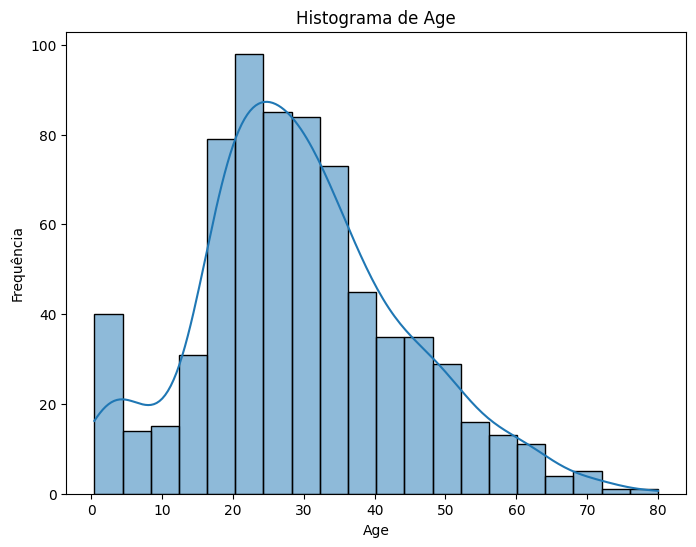

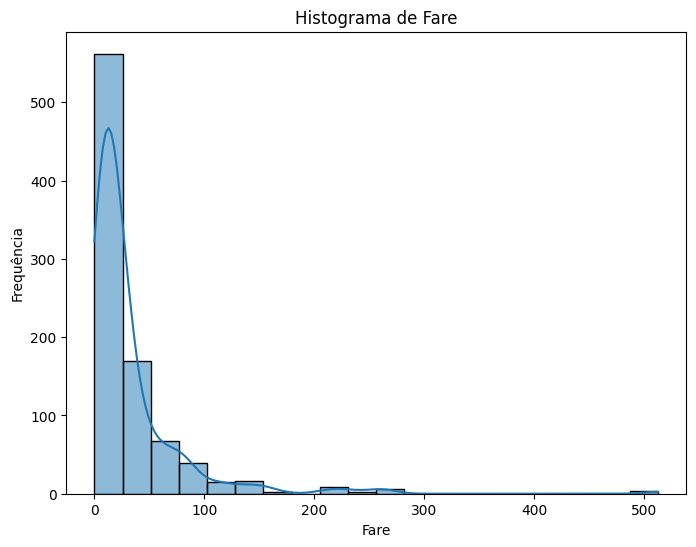

In [ ]:
# Gerar histogramas para as variáveis numéricas
for column in df.columns: # vamos fazer para todas
  if pd.api.types.is_numeric_dtype(df[column]):
    plt.figure(figsize=(8, 6))
    sns.histplot(df[column], kde=True,bins=20) # bins: podemos alterar para encontra padrões
    plt.title(f'Histograma de {column}')
    plt.xlabel(column)
    plt.ylabel('Frequência')
    plt.show()


Um ponto central é analisarmos a distribuição dos dados quanto a sua normalidade. Podemos usar elementos gráficos como o QQ-plot. para melhor fazê-lo, a linha reta mostra como deveria ser a distribuição teórica em termos de quantis

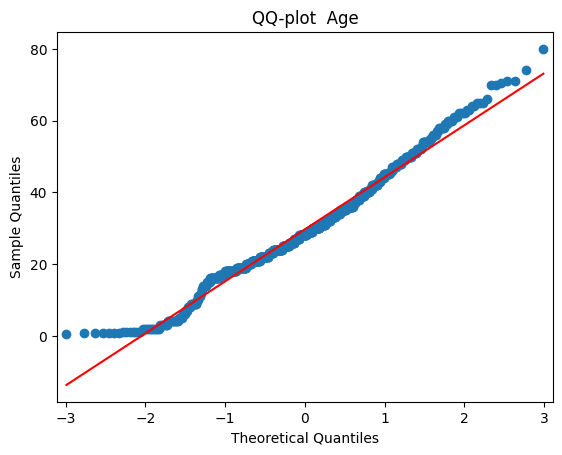

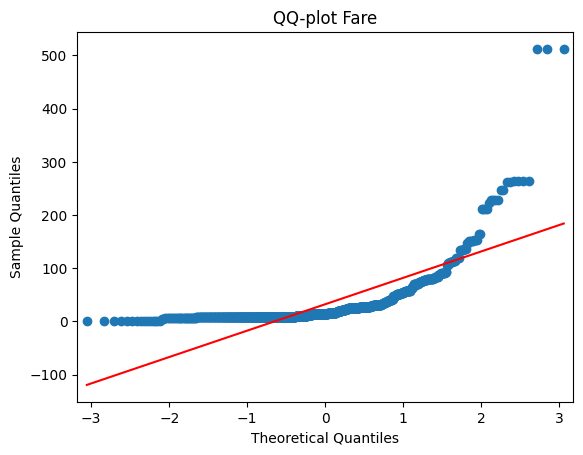

In [ ]:
# QQ-plot
sm.qqplot(df['Age'].dropna(), line='s')
plt.title('QQ-plot  Age')
plt.show()

# QQ-plot
sm.qqplot(df['Fare'].dropna(), line='s')
plt.title('QQ-plot Fare')
plt.show()

Podemos utilizar testes estatísticos de normalidade como Shapiro-Wilk e Kolmogorov-Smirnov, lembrando que H0: é uma distribuição normal, logo p-valor < 0.05 rejeita a distribuição normal


In [ ]:
from scipy.stats import shapiro, kstest ,jarque_bera

# teste de Shapiro-Wilk para verificar a normalidade (n<1000) teste padrão, bem sensivel, rigoroso
shapiro_stat, shapiro_pvalue = shapiro(df['Age'].dropna()) # H0 é destribuição normal, para isso P>0.05
print(f"Shapiro-Wilk p-value: {shapiro_pvalue:.4f}")

# teste de Kolmogorov-Smirnov para verificar a normalidade, n>1000, pouco criterioso, usa para compara com outras distribuições
ks_stat, ks_pvalue = kstest(df['Age'].dropna(), 'norm') # H0 é que os dados vieram de uma destribuição normal, para isso P>0.05
print(f"Kolmogorov-Smirnov p-value: {ks_pvalue:.4f}")

# teste de jarque_bera para verificar a normalidade, para grandes amostras, baseados em assimetria e curtose
jb_stat, jb_pvalue = jarque_bera(df['Age'].dropna()) # H0 é que os dados vieram de uma destribuição normal, para isso P>0.05
print(f"Jarque-Bera p-value: {jb_pvalue:.4f}")

Shapiro-Wilk p-value: 0.0000
Kolmogorov-Smirnov p-value: 0.0000
Jarque-Bera p-value: 0.0001


O boxplot é outra maneira comumente utilizada para observação de variáveis numéricas. Util para identifcar outliers pelo processo de diferença interquantis, bem como a variabilidade dos dados.

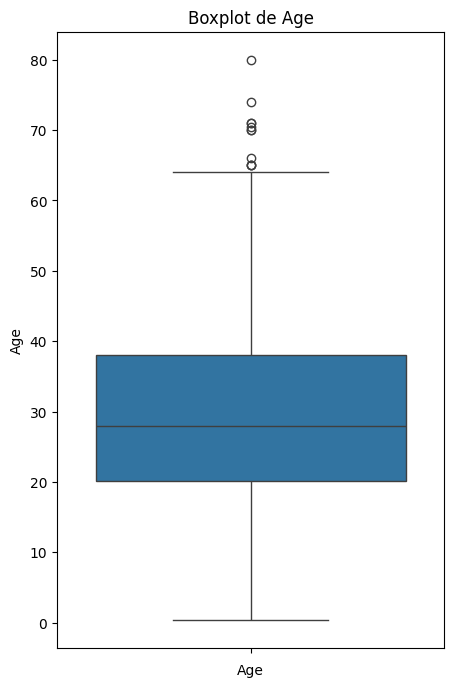

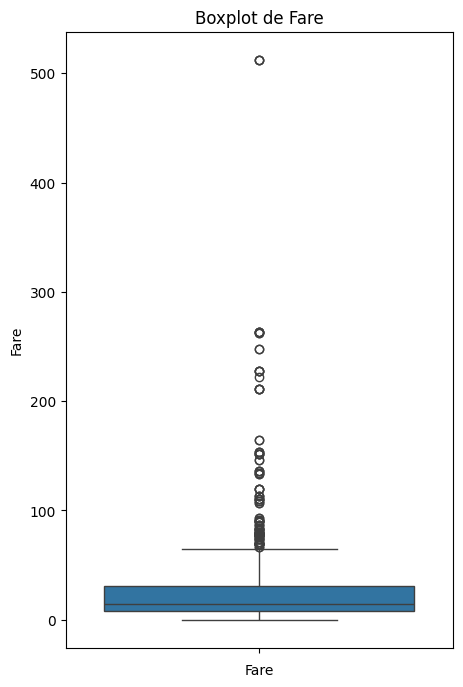

In [ ]:
# boxplots para as variáveis numéricas
for column in df.columns:
  if pd.api.types.is_numeric_dtype(df[column]):
    plt.figure(figsize=(5, 8))
    sns.boxplot(y=df[column])
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.show()
    print("")


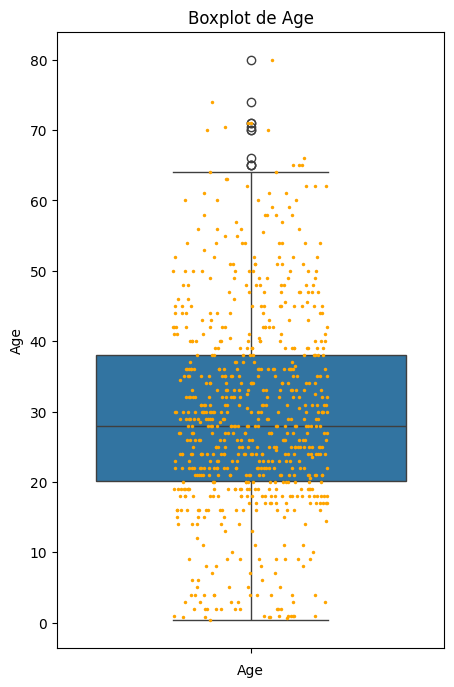

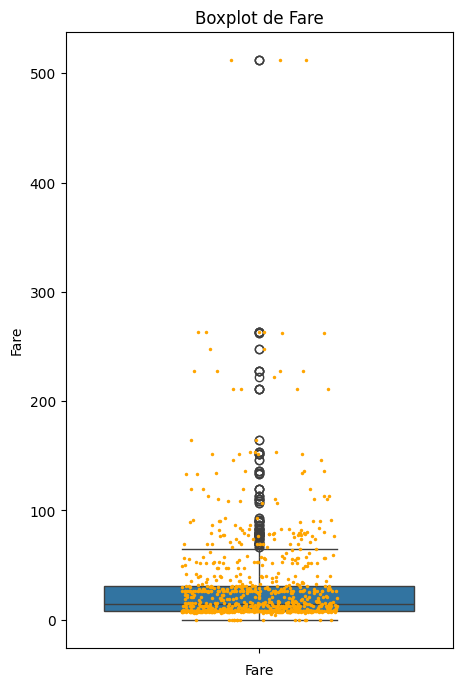

In [ ]:
# boxplots para as variáveis numéricas
for column in df.columns:
  if pd.api.types.is_numeric_dtype(df[column]):
    plt.figure(figsize=(5, 8))
    sns.boxplot(y=df[column])
    sns.stripplot(y=df[column], color='orange',jitter=0.2, size=2.5)
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.show()
    print("")

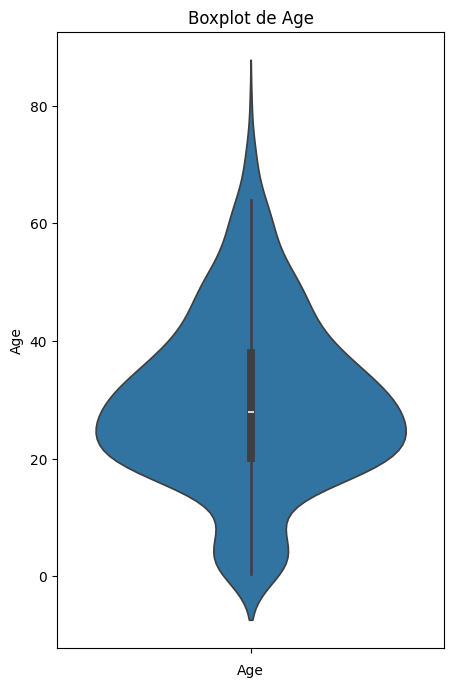

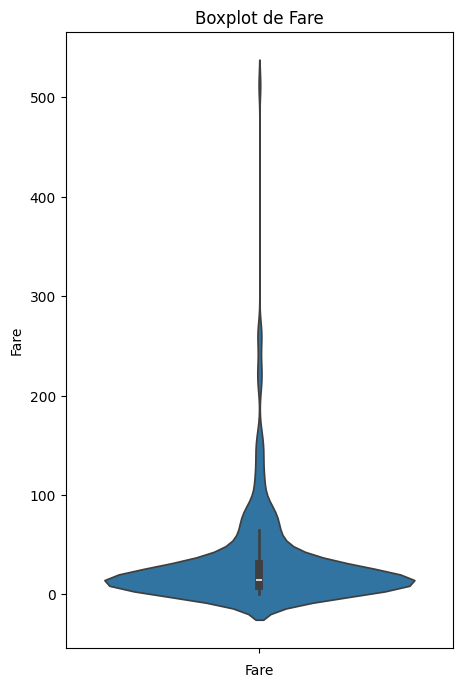

In [ ]:
# violino
for column in df.columns:
  if pd.api.types.is_numeric_dtype(df[column]):
    plt.figure(figsize=(5, 8))
    sns.violinplot(y=df[column])
    plt.title(f'Boxplot de {column}')
    plt.xlabel(column)
    plt.show()
    print("")

# Variaveis Categoricas

Iniciamos observando em forma de tabela de frequencias, podendo ser relativas e absolutas

In [ ]:
# Percentual de cada categoria

df['Sex'].value_counts(normalize=True) * 100 # normalizado sai em porcentagem 0-1

,proportion
Sex,
male,64.758698
female,35.241302


In [ ]:
df['Survived'].value_counts(normalize=True) * 100

,proportion
Survived,
0,61.616162
1,38.383838


In [ ]:
df['Pclass'].value_counts(normalize=True) * 100

,proportion
Pclass,
3,55.106622
1,24.242424
2,20.650954


Podemos representar graficamente a informação da tabela, nosso objetivo é identificar se estamos lidando com um problema de classe rara, onde temos uma variavel alvo desbalanceada drasticamente.




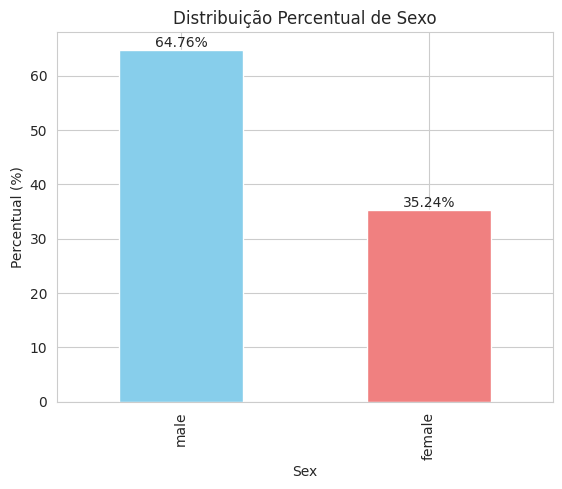

,proportion
Sex,
male,64.758698
female,35.241302


In [ ]:
sex_dist=df['Sex'].value_counts(normalize=True) * 100

# gráfico de barras
sex_dist.plot(kind='bar', color=['skyblue', 'lightcoral'])

# posisionar o valor de %
for i, valor in enumerate(sex_dist):
    plt.text(i, valor, f'{valor:.2f}%', ha='center', va='bottom')

plt.ylabel('Percentual (%)')
plt.title('Distribuição Percentual de Sexo')

plt.show()
sex_dist # tabela

In [ ]:
# caso for de interesse saber numero absoluto
counts = df['Survived'].value_counts()
percentages = df['Survived'].value_counts(normalize=True) * 100

# Calcular as porcentagens
pd.DataFrame({'Counts': counts, 'Percentages': percentages})

,Counts,Percentages
Survived,,
0,549,61.616162
1,342,38.383838


# Analise Multivariada

Agora vamos buscar a relação entre as variáveis. usaremos recuros distintos para cada combinação, numerica x numerica, categorica x numerica e categorica x categorica. Os recursos visuais são as nossa principal ferramenta. para isso recomendo acompanhar esse guia de quais graficos são recomendados em cada condição: [Guia Graficos](https://www.data-to-viz.com/)

### Numérico x Categorico

Vamos analisar diversas combinações de variveis numéricas com categoricas (alvo ou não)

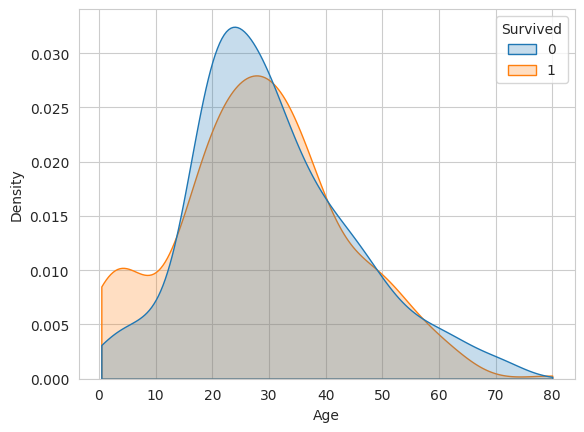

In [ ]:
# graficos de Kernel Density Estimate - estimativa suave da densidade
# note que o argumento Common_norm iguala os tamanhos das areas, bom para comparar quando temos classes desbalanceadas
sns.kdeplot(data=df,x="Age",hue='Survived',fill=True,common_norm=False, clip=(df['Age'].min(),df['Age'].max())  )

plt.show()

Os testes estatísticos tradicionais **avaliam se as diferenças observadas nos dados** (como médias, proporções ou variâncias) podem ser atribuídas **ao acaso**, ou se são suficientemente grandes para sugerir que existe **um efeito real** entre os grupos ou condições comparadas. lembrando:

Os testes parametricos: t-studente (2 grupos), ANOVA(3+ grupos), sendo que a teoria do limite central permite a aplicação a dados não normais, porem sempre ponderar o tamanho dos dados, sua assimetria e outliers. n>1000 mesmo que com assimetrias grandes(>3) podem ser aplicados, nos demais casos ponderar e preferir não parametricos.

In [ ]:
import scipy.stats as stats
# teste Mann-Whitney usa mediana
mw_stat, mw_pvalue = stats.mannwhitneyu(df[df['Survived'] == 0]['Age'].dropna(),
                               df[df['Survived'] == 1]['Age'].dropna())
print(f"Mann-Whitney U test p-value: {mw_pvalue:.4f}")

# teste t-test usa media, p-value<0.05 para H0 ( Não existe diferença estatisticamente significativa entre as médias dos grupos analisados) ser rejeitada
ttest_stat, ttest_pvalue = stats.ttest_ind(df[df['Survived'] == 0]['Age'].dropna(),
                               df[df['Survived'] == 1]['Age'].dropna())
print(f"T-test p-value: {ttest_pvalue:.4f}")

Mann-Whitney U test p-value: 0.1605
T-test p-value: 0.0391


Note que um teste diz que temos diferença casual, outro não, então como fazer?

In [ ]:
# vamos ver o porque.
display(df[df['Survived'] == 0]['Age'].dropna().describe())
display(df[df['Survived'] == 1]['Age'].dropna().describe())


,Age
count,424.000000
mean,30.626179
std,14.172110
min,1.000000
25%,21.000000
50%,28.000000
75%,39.000000
max,74.000000


,Age
count,290.000000
mean,28.343690
std,14.950952
min,0.420000
25%,19.000000
50%,28.000000
75%,36.000000
max,80.000000


In [ ]:
# vamos ver se temos alguma homogeneidade da variancia entra as amostras
from scipy.stats import levene

# Aplica o teste de Levene para homogeneidade de variâncias
# H0 (hipótese nula): as variâncias dos grupos são iguais (homogeneidade)
# H1 (hipótese alternativa): as variâncias dos grupos são diferentes
statistic, pvalue = levene(df[df['Survived'] == 0]['Age'].dropna(),
                           df[df['Survived'] == 1]['Age'].dropna())

print(f"Levene's test statistic: {statistic:.4f}")
print(f"Levene's test p-value: {pvalue:.4f}")

if pvalue < 0.05:
    print("As variâncias das idades entre os grupos 'Não Sobreviveu' e 'Sobreviveu' são significativamente diferentes (rejeitamos H0).")
else:
    print("Não há evidência suficiente para rejeitar a hipótese nula de que as variâncias das idades são iguais entre os grupos.")

Levene's test statistic: 1.1954
Levene's test p-value: 0.2746
Não há evidência suficiente para rejeitar a hipótese nula de que as variâncias das idades são iguais entre os grupos.


Um jeito pratico de analisarmos variaves numericas com categoricas é trasnformar os valores continuos em categorias (intervalos)

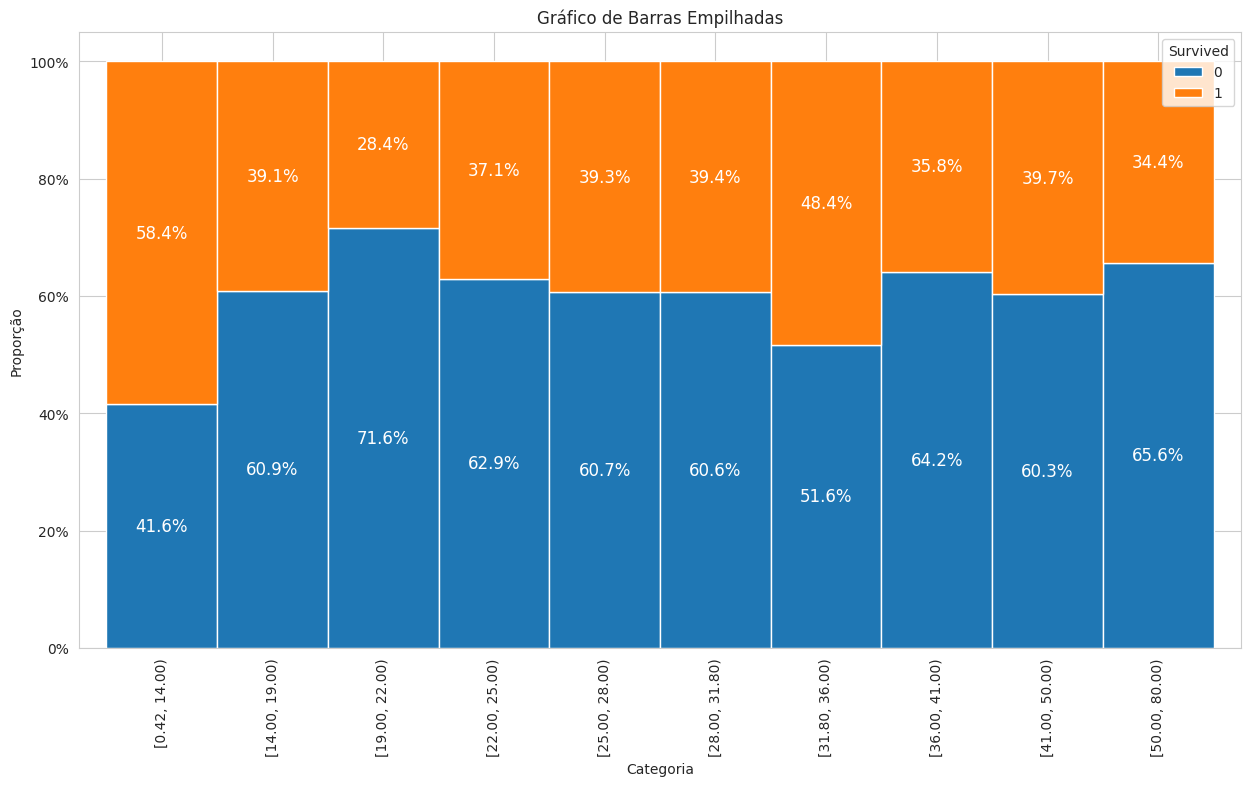

In [ ]:
from matplotlib.ticker import PercentFormatter

#passar valores numericos para intervalos (categoricos)
# note que os intervalor vão ter os mesmos numeros de elementos "qcut", use "cut" para ter intervalos iguais de valores(bins)
#df['fare_interval'] = pd.qcut(df['age'], q=10, labels=[f"Q{i+1}" for i in range(10)])
df['age_quantile'], bins = pd.qcut(df['Age'], q=10, labels=False, retbins=True)

#>>>>>>> Exemplo definindo nossos cortes<<<<<<<<
#age_bins = [0, 17, 35, 60, float('inf')]

# Definir os nomes (labels) para esses bins
#age_labels = ['Jovem', 'Adulto', 'Meia-idade', 'Idoso']

#right=True (padrão) significa que o bin (17, 35] inclui 35.
# right=False significa que o bin [0, 17) incluiria 0 e 16, mas não 17.
#df['age_group_manual'] = pd.cut(df['Age'],
#                                bins=age_bins,
#                                labels=age_labels,
#                                right=True)
                                # ou use labels=False para obter 0, 1, 2, 3
#>>>>>>>>>>>>>>>><<<<<<<<<<<<<<<<<

# Criar uma tabela de contingência (cross-tab) para categorias
cross_tab = pd.crosstab(df['age_quantile'], df['Survived'],  normalize='index')



# Plotar as barras empilhadas
ax=cross_tab.plot(kind='bar', stacked=True,width=1,figsize=(15,8))

interval_labels = [f'[{bins[i]:.2f}, {bins[i+1]:.2f})' for i in range(len(bins)-1)]
ax.set_xticklabels(interval_labels)


# Adicionar rótulos e título
plt.title('Gráfico de Barras Empilhadas')
plt.ylabel('Proporção')
plt.xlabel('Categoria')
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1)) #porcentagem

for p in ax.patches:
    width = p.get_width()    # Largura da barra
    height = p.get_height()  # Altura da barra (proporção)
    x, y = p.get_xy()        # Posição da barra
    if height > 0:           # Adicionar porcentagem se houver altura
        ax.text(x + width / 2, y + height / 2, f'{height:.1%}',
                ha='center', va='center', color='white', fontsize=12)

# Exibir o gráfico
plt.show()


Vamos analisar agora como é a relação entre a taxa paga pelos passageiros com a sobrevivencia

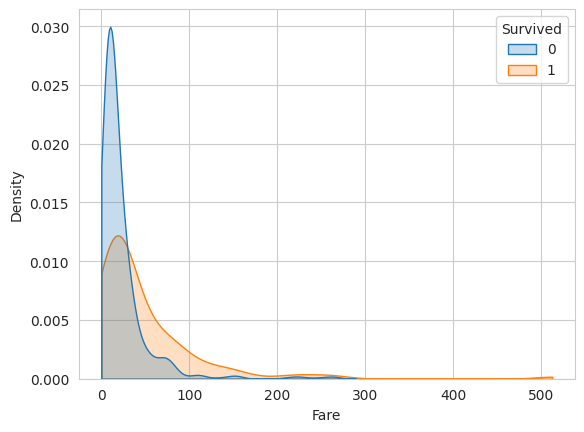

In [ ]:
# graficos de distribuição de densidade
sns.kdeplot(data=df,x="Fare",hue='Survived',fill=True,common_norm=False,clip=(df['Fare'].min(),df['Fare'].max() ))

plt.show()

In [ ]:
# vamos aplicar os testes estatisticos
# teste Mann-Whitney U usa mediana para 'Fare'
mw_stat_fare, mw_pvalue_fare = stats.mannwhitneyu(df[df['Survived'] == 0]['Fare'].dropna(),
                                               df[df['Survived'] == 1]['Fare'].dropna())
print(f"Mann-Whitney U test (Fare) p-value: {mw_pvalue_fare:.4f}")

# teste t-test usa média para 'Fare'
ttest_stat_fare, ttest_pvalue_fare = stats.ttest_ind(df[df['Survived'] == 0]['Fare'].dropna(),
                                                  df[df['Survived'] == 1]['Fare'].dropna())
print(f"T-test (Fare) p-value: {ttest_pvalue_fare:.4f}")

levene_stat_fare, levene_pvalue_fare = stats.levene(df[df['Survived'] == 0]['Fare'].dropna(),
                                                  df[df['Survived'] == 1]['Fare'].dropna())
print(f"levene (Fare) p-value: {levene_pvalue_fare:.4f}")



Mann-Whitney U test (Fare) p-value: 0.0000
T-test (Fare) p-value: 0.0000
levene (Fare) p-value: 0.0000


In [ ]:
# vamos ver o porque.
display(df[df['Survived'] == 0]['Fare'].dropna().describe())
display(df[df['Survived'] == 1]['Fare'].dropna().describe())

,Fare
count,549.000000
mean,22.117887
std,31.388207
min,0.000000
25%,7.854200
50%,10.500000
75%,26.000000
max,263.000000


,Fare
count,342.000000
mean,48.395408
std,66.596998
min,0.000000
25%,12.475000
50%,26.000000
75%,57.000000
max,512.329200


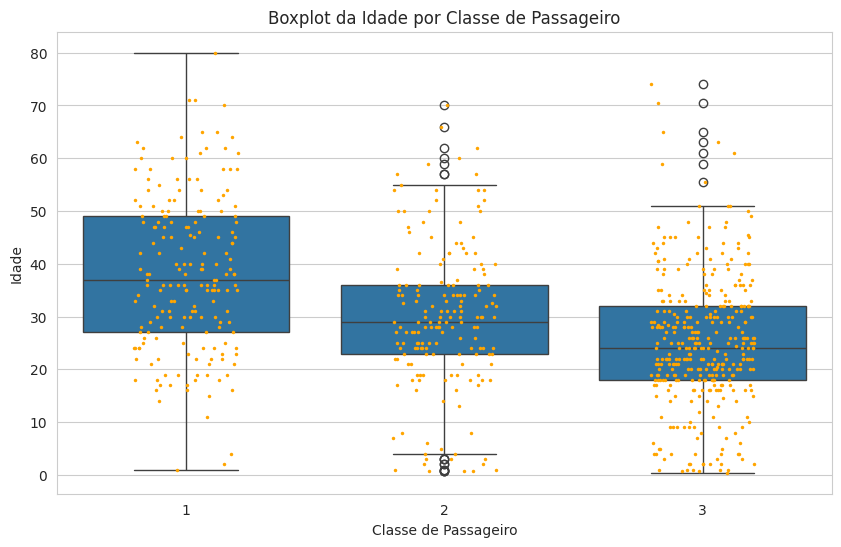

In [ ]:
# relacionar por meio de boxplot as idades pela classe

plt.figure(figsize=(10, 6))
sns.boxplot(x='Pclass', y='Age', data=df)
plt.title('Boxplot da Idade por Classe de Passageiro')
plt.xlabel('Classe de Passageiro')
plt.ylabel('Idade')

# Adicionar os pontos individuais ao boxplot
#sns.stripplot(x='Pclass', y='Age', data=df, color='black', size=3, jitter=True)

plt.show()


Testes parametricos para mais de uma amostra são empregafos ANOVA(Parametrico) e Kruskal-Wallis (não parametrico)

In [ ]:
from scipy.stats import f_oneway

# Kruskal-Wallis (numérico x categórico, não paramétrico): Testa se há diferenças significativas entre as distribuições
kw_stat, kw_pvalue = kruskal(df[df['Pclass'] == 1]['Age'].dropna(),
                               df[df['Pclass'] == 2]['Age'].dropna(),
                               df[df['Pclass'] == 3]['Age'].dropna())
print(f"Kruskal-Wallis test p-value: {kw_pvalue:.4f}")

# ANOVA (paramétrico): Testa se há diferenças significativas entre as médias dos grupos
# Atenção: ANOVA assume normalidade e homogeneidade das variâncias (TLC não da cobertura a este aspecto).
# Vimos que a variável 'Age' não segue uma distribuição normal(homogeneidade das variâncias), então o Kruskal-Wallis pode ser mais apropriado aqui.
anova_stat, anova_pvalue = f_oneway(df[df['Pclass'] == 1]['Age'].dropna(),
                                   df[df['Pclass'] == 2]['Age'].dropna(),
                                   df[df['Pclass'] == 3]['Age'].dropna())
print(f"ANOVA test p-value: {anova_pvalue:.4f}")

Kruskal-Wallis test p-value: 0.0000
ANOVA test p-value: 0.0000


### Categorico x categorico

Para comparação entre categóricos o melhor recurso é a Tabela de contingencia e suas formas gráficas de representá-la

Survived         0         1
Sex                         
female    0.257962  0.742038
male      0.811092  0.188908


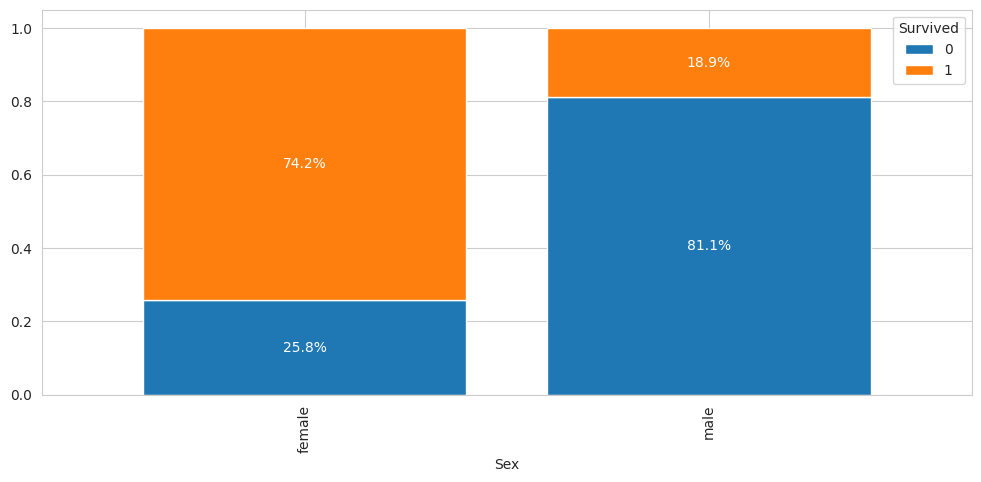

In [ ]:
cross_tab = pd.crosstab(df['Sex'], df['Survived'],  normalize='index') # tabela de contigencia
print(cross_tab)
ax=cross_tab.plot(kind='bar', stacked=True,width=0.8,figsize=(12,5))
for p in ax.patches:
    width = p.get_width()    # Largura da barra
    height = p.get_height()  # Altura da barra (proporção)
    x, y = p.get_xy()        # Posição da barra
    if height > 0:           # Adicionar porcentagem se houver altura
        ax.text(x + width / 2, y + height / 2, f'{height:.1%}',
                ha='center', va='center', color='white', fontsize=10)
plt.show()

O teste qui-quadrado verifica se existe associação entre variáveis categóricas, comparando frequências observadas com frequências esperadas sob a hipótese de independência.

In [ ]:
from scipy.stats import chi2_contingency

# Criar a tabela de contingência (cross-tab) para Sexo e Sobrevivência
cross_tab_sex_survived = pd.crosstab(df['Sex'], df['Survived'])

# Realizar o teste qui-quadrado: p < 0.05 rejeita H0, significa:
#Os dados observados são incompatíveis com a hipótese de independência, logo pode haver associação entre as variaveis
chi2, p, dof, expected = chi2_contingency(cross_tab_sex_survived)

print(f"Valor p: {p:.4f}, Chu2: {chi2:.4f}")



Valor p: 0.0000, Chu2: 260.7170


Pclass           1         2         3
Survived                              
0         0.145719  0.176685  0.677596
1         0.397661  0.254386  0.347953


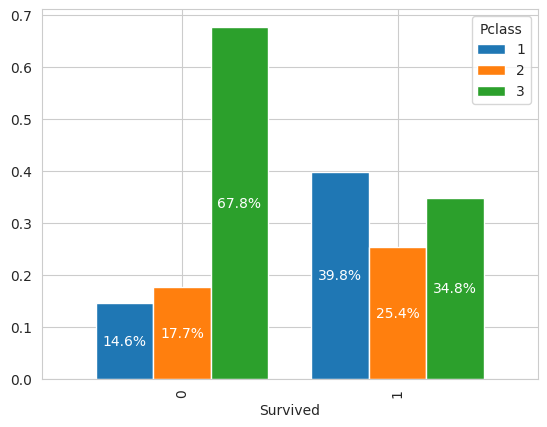

In [ ]:
# vamos comparar sobrevivencia com a classe dos passageiros

cross_tab = pd.crosstab(df['Survived'], df['Pclass'],  normalize='index')
print(cross_tab)
ax=cross_tab.plot(kind='bar', stacked=False,width=0.8 )
for p in ax.patches:
    width = p.get_width()    # Largura da barra
    height = p.get_height()  # Altura da barra (proporção)
    x, y = p.get_xy()        # Posição da barra
    if height > 0:           # Adicionar porcentagem se houver altura
        ax.text(x + width / 2, y + height / 2, f'{height:.1%}',
                ha='center', va='center', color='white', fontsize=10)
plt.show()




In [ ]:

# Criar a tabela de contingência (cross-tab) SEM normalização para o teste qui-quadrado
cross_tab_chi2 = pd.crosstab(df['Survived'], df['Pclass'])

# Realizar o teste qui-quadrado: p < 0.05 rejeita H0, significa:
# Os dados observados são incompatíveis com a hipótese de independência, logo pode haver associação entre as variaveis
chi2, p, dof, expected = chi2_contingency(cross_tab_chi2)

print(f"Valor p: {p:.4f}")

Valor p: 0.0000


Graficos avançados

/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the stripplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)
/usr/local/lib/python3.10/dist-packages/seaborn/axisgrid.py:186: UserWarning: You have mixed positional and keyword arguments, some input may be discarded.
  figlegend = self._figure.legend(handles, labels, **kwargs)


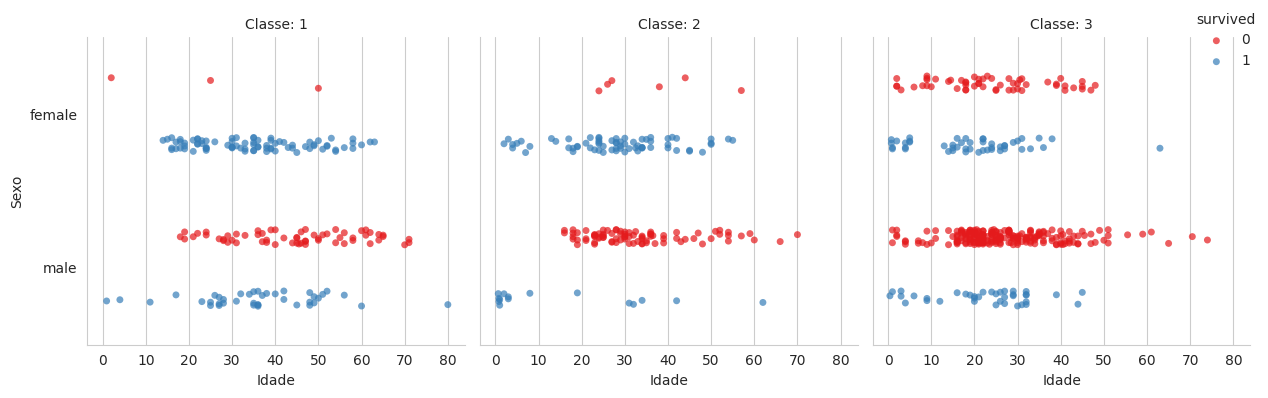

In [ ]:

# Criar o gráfico usando FacetGrid (separa as classes)
g = sns.FacetGrid(df, col='Pclass', height=4, aspect=1)

g.map(sns.stripplot, 'Age', 'Sex', hue='Survived', data=df, jitter=True, dodge=True, palette='Set1', alpha=0.7)

# Adicionar título e legendas
g.set_titles(col_template="Classe: {col_name}")
g.set_axis_labels("Idade", "Sexo")
g.add_legend(title='survived', loc='upper right', labels=['0', '1'])

# Ajustar o layout e mostrar o gráfico
plt.tight_layout()
plt.show()

### Manipulação de variaveis

Vamos tentar extrair informação do Nome dos passageiros

In [ ]:
# selecionar qualquer sequencia de caracter que termine em ponto.
df['Titulo'] = df['Name'].str.extract(r'([A-Za-z]+)\.')
df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Titulo
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,Mr
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,Mrs
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,Miss
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,Mrs
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,Mr


In [ ]:
# vamos visualisar quanto nomes temos
counts = df['Titulo'].value_counts()
percentages = df['Titulo'].value_counts(normalize=True) * 100

# Calcular as porcentagens
counts=pd.DataFrame({'Counts': counts, 'Percentages': percentages})
counts

,Counts,Percentages
Titulo,,
Mr,517,58.024691
Miss,182,20.426487
Mrs,125,14.029181
Master,40,4.489338
Dr,7,0.785634
Rev,6,0.673401
Mlle,2,0.224467
Major,2,0.224467
Col,2,0.224467


In [ ]:
# vamos transformar os valores menores em "Outros"
df['Titulo'] = np.where(df['Titulo'].isin(counts[counts['Counts'] > 7].index), df['Titulo'], 'Outros')
df['Titulo'].value_counts()

,count
Titulo,
Mr,517
Miss,182
Mrs,125
Master,40
outros,27


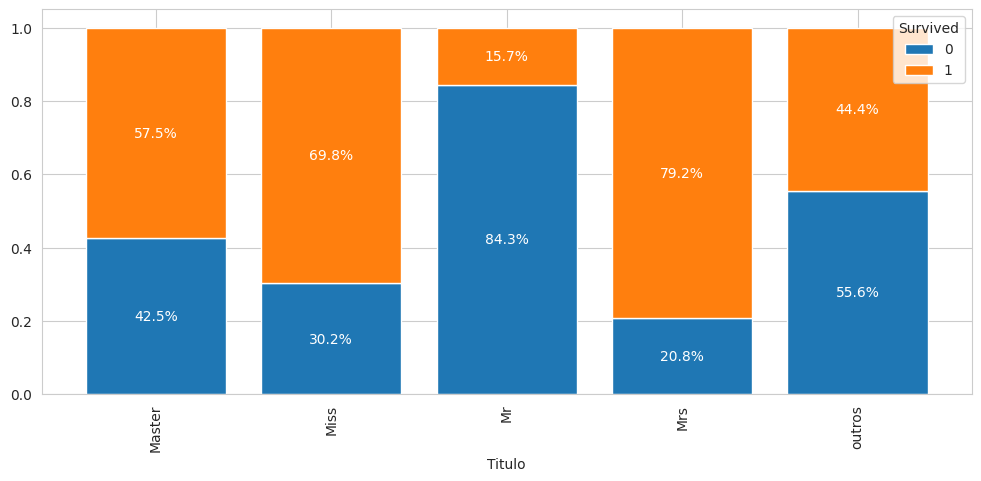

In [ ]:
# vamos ver como se distribuem

cross_tab=pd.crosstab(df['Titulo'], df['Survived'],  normalize='index')
ax=cross_tab.plot(kind='bar', stacked=True,width=0.8,figsize=(12,5))
for p in ax.patches:
    width = p.get_width()    # Largura da barra
    height = p.get_height()  # Altura da barra (proporção)
    x, y = p.get_xy()        # Posição da barra
    if height > 0:           # Adicionar porcentagem se houver altura
        ax.text(x + width / 2, y + height / 2, f'{height:.1%}',
                ha='center', va='center', color='white', fontsize=10)
plt.show()

In [ ]:

# podemos criar a variavel familia
# Somar 'SibSp' e 'Parch' +1 para obter o tamanho total da familia
df['SibSp'] = pd.to_numeric(df['SibSp'], errors='coerce')
df['Parch'] = pd.to_numeric(df['Parch'], errors='coerce')
df['Familia'] = df['SibSp'] + df['Parch'] +1

df.head()

,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Titulo,age_quantile,Familia
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,Mr,2.0,2
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,Mrs,7.0,2
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,Miss,4.0,1
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,Mrs,6.0,2
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,Mr,6.0,1


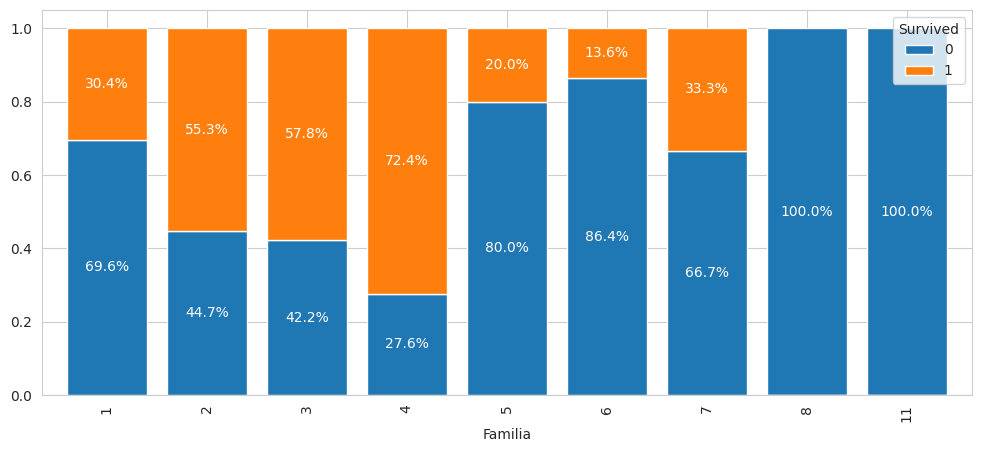

,0
Familia,
1,537
2,161
3,102
4,29
5,15
6,22
7,12
8,6
11,7


In [ ]:
cross_tab=pd.crosstab(df['Familia'], df['Survived'],  normalize='index')
ax=cross_tab.plot(kind='bar', stacked=True,width=0.8,figsize=(12,5))
for p in ax.patches:
    width = p.get_width()    # Largura da barra
    height = p.get_height()  # Altura da barra (proporção)
    x, y = p.get_xy()        # Posição da barra
    if height > 0:           # Adicionar porcentagem se houver altura
        ax.text(x + width / 2, y + height / 2, f'{height:.1%}',
                ha='center', va='center', color='white', fontsize=10)
plt.show()
pd.crosstab(df['Familia'], df['Survived']).sum(axis=1)

In [ ]:
#Podemos fazer algumas perguntas aos dados.
# maioria homem solo?
len(df[(df['Sex'] == 'male') & (df['Familia'] == 1)])
# Mulheres adultas?
#len(df[(df['Sex'] != 'male') & (df['Age'] > 14)])

411

Modelo, podemos passear aqui depois

<ipython-input-88-0e43848bdc4e>:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Sex'] = le_sex.fit_transform(X['Sex'])


Precisão do modelo: 0.8212290502793296


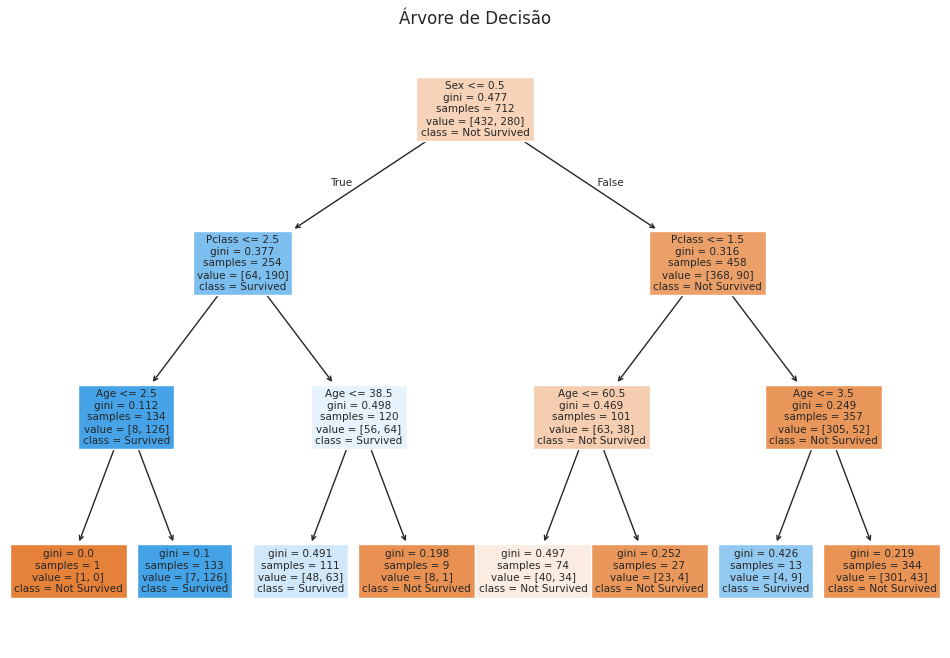

In [ ]:
from sklearn.tree import DecisionTreeClassifier,  plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder



X = df[['Pclass', 'Sex', 'Age']]  # Selecionar váriaveis (colunas) forçantes
y = df['Survived'] # Alvo (dependente)

# Codificar a variável categórica 'Sex'
le_sex = LabelEncoder()
X['Sex'] = le_sex.fit_transform(X['Sex'])


# Dividir os dados em conjuntos de treinamento e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=24)

# Criar o modelo de árvore de decisão
model = DecisionTreeClassifier(max_depth=3, random_state=24)

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar a precisão do modelo
accuracy = accuracy_score(y_test, y_pred)
print("Precisão do modelo:", accuracy)

# Visualizar a árvore de decisão
plt.figure(figsize=(12, 8))
plot_tree(model, feature_names=X.columns, class_names=['Not Survived', 'Survived'], filled=True)
plt.title('Árvore de Decisão')
plt.show()

In [ ]:
#matrix de confusão
cm=confusion_matrix(y_test, y_pred)
cm_df=pd.DataFrame(cm, index=['Prev. Not Survived', 'Prev. Survived'], columns=['Not Survived', 'Survived'])
cm_df

,Not Survived,Survived
Prev. Not Survived,103,14
Prev. Survived,23,39


In [ ]:
# Gerar o relatório de métricas
relatorio = classification_report(y_test, y_pred)

# Exibir o relatório
print(relatorio)

              precision    recall  f1-score   support

           0       0.86      0.87      0.86       117
           1       0.75      0.73      0.74        62

    accuracy                           0.82       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.82      0.82      0.82       179



###EDA Automatica

In [ ]:
#!pip install sweetviz
# necessario dowgrade do numpy

import sweetviz as sv

# Converter 'Survived' para tipo numérico, se for categórico
# sweetviz espera o target como NUMERICAL ou BOOLEAN
if df['Survived'].dtype == 'category':
    df['Survived'] = df['Survived'].astype('int64')

report = sv.analyze(df, target_feat='Survived')

#report.show_notebook() # para mostrar direto no notebook
report.show_html()

In [ ]:
#!pip install ydata-profiling
from ydata_profiling import ProfileReport


profile = ProfileReport(df, title="Relatório EDA", explorative=True)
profile.to_file("relatorio.html")

# gerar relatorio
#report=ProfileReport(df)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 8/8 [00:00<00:00, 57.50it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]